# 🔵 Ejercicio de Clustering con K-Means

En este notebook aprenderás a aplicar el algoritmo **K-Means** paso a paso:

1. Generar datos sintéticos
2. Visualizar los datos antes del clustering
3. Aplicar K-Means con `scikit-learn`
4. Visualizar los clusters resultantes
5. Usar el **Método del Codo** para encontrar el K óptimo
6. Evaluar con el **Coeficiente de Silhouette**

---

## 1. Importar librerías

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

# Reproducibilidad
np.random.seed(42)

print('Librerías importadas correctamente')

Librerías importadas correctamente


## 2. Generar datos sintéticos

In [3]:
# Generamos 300 puntos con 4 centros (grupos reales)
X, y_real = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

# Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Forma del dataset: {X_scaled.shape}')
print(f'Primeras 5 filas:\n{X_scaled[:5].round(3)}')

Forma del dataset: (300, 2)
Primeras 5 filas:
[[-1.107  0.612]
 [-1.168  0.672]
 [ 0.296  0.837]
 [-0.696 -1.427]
 [-1.347  0.592]]


## 3. Visualizar los datos (sin etiquetas)

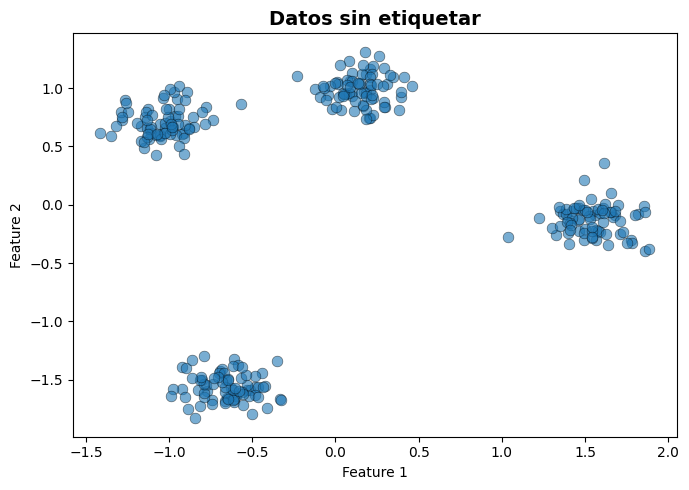

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.6, edgecolors='k', linewidths=0.4, s=60)
plt.title('Datos sin etiquetar', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

## 4. Aplicar K-Means con K=4

In [5]:
# Crear y ajustar el modelo
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',   # Inicialización inteligente
    n_init=10,          # 10 inicializaciones aleatorias
    max_iter=300,
    random_state=42
)

kmeans.fit(X_scaled)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print(f'Inercia (WCSS): {kmeans.inertia_:.2f}')
print(f'Iteraciones hasta convergencia: {kmeans.n_iter_}')
print(f'Centroides:\n{centroids.round(3)}')

Inercia (WCSS): 11.32
Iteraciones hasta convergencia: 2
Centroides:
[[ 0.146  0.99 ]
 [-0.656 -1.563]
 [ 1.545 -0.132]
 [-1.035  0.705]]


## 5. Visualizar los clusters

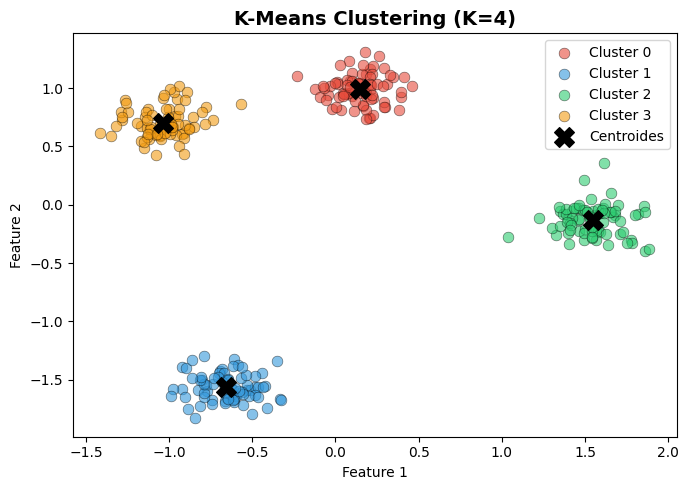

In [6]:
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']

plt.figure(figsize=(7, 5))

for i in range(4):
    mask = labels == i
    plt.scatter(
        X_scaled[mask, 0], X_scaled[mask, 1],
        color=colors[i], alpha=0.6, edgecolors='k',
        linewidths=0.4, s=60, label=f'Cluster {i}'
    )

# Dibujar centroides
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    color='black', marker='X', s=200,
    zorder=5, label='Centroides'
)

plt.title('K-Means Clustering (K=4)', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Método del Codo (Elbow Method)
Usamos la inercia (WCSS) para encontrar el K óptimo.

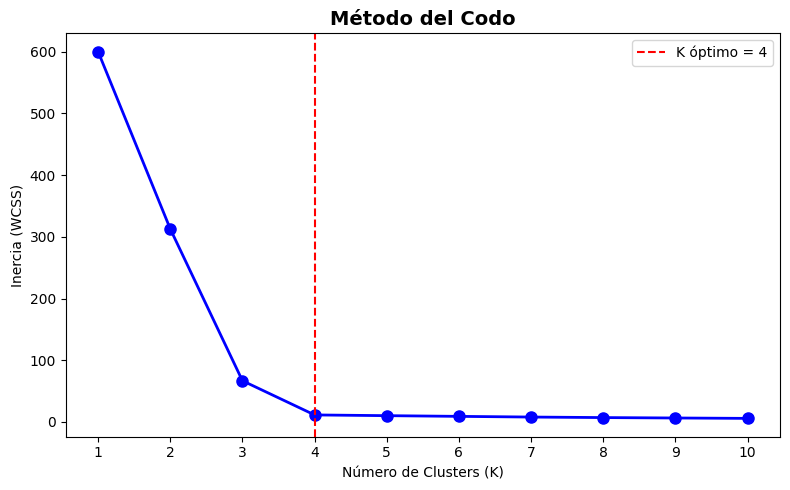

El "codo" indica el K óptimo donde agregar más clusters ya no mejora significativamente.


In [7]:
inercias = []
rango_k = range(1, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercias, 'bo-', markersize=8, linewidth=2)
plt.axvline(x=4, color='red', linestyle='--', label='K óptimo = 4')
plt.title('Método del Codo', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (WCSS)')
plt.xticks(rango_k)
plt.legend()
plt.tight_layout()
plt.show()

print('El "codo" indica el K óptimo donde agregar más clusters ya no mejora significativamente.')

## 7. Coeficiente de Silhouette
Mide qué tan bien separados están los clusters. Va de -1 a 1 (más cerca de 1 es mejor).

K=2: Silhouette = 0.5700
K=3: Silhouette = 0.7642
K=4: Silhouette = 0.8386
K=5: Silhouette = 0.7082
K=6: Silhouette = 0.5767
K=7: Silhouette = 0.4564
K=8: Silhouette = 0.3362
K=9: Silhouette = 0.3509
K=10: Silhouette = 0.3675


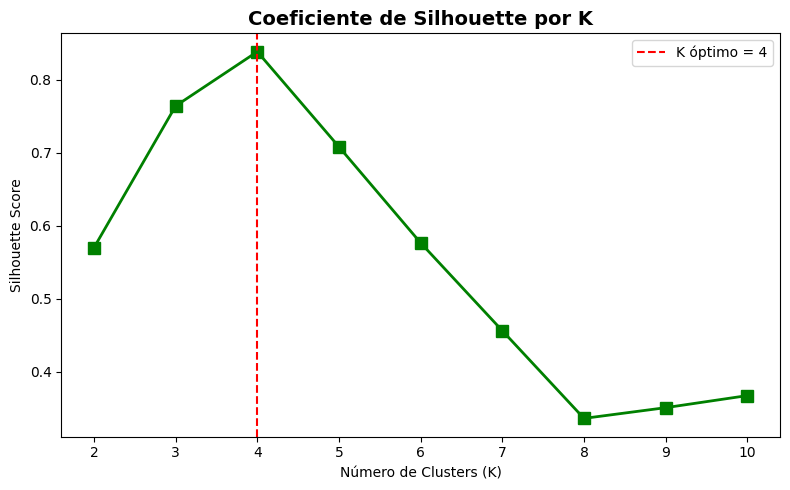

In [8]:
silhouette_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    preds = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, preds)
    silhouette_scores.append(score)
    print(f'K={k}: Silhouette = {score:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, 'gs-', markersize=8, linewidth=2)
plt.axvline(x=4, color='red', linestyle='--', label='K óptimo = 4')
plt.title('Coeficiente de Silhouette por K', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.legend()
plt.tight_layout()
plt.show()

## 8. Gráfico de Silhouette detallado (K=4)

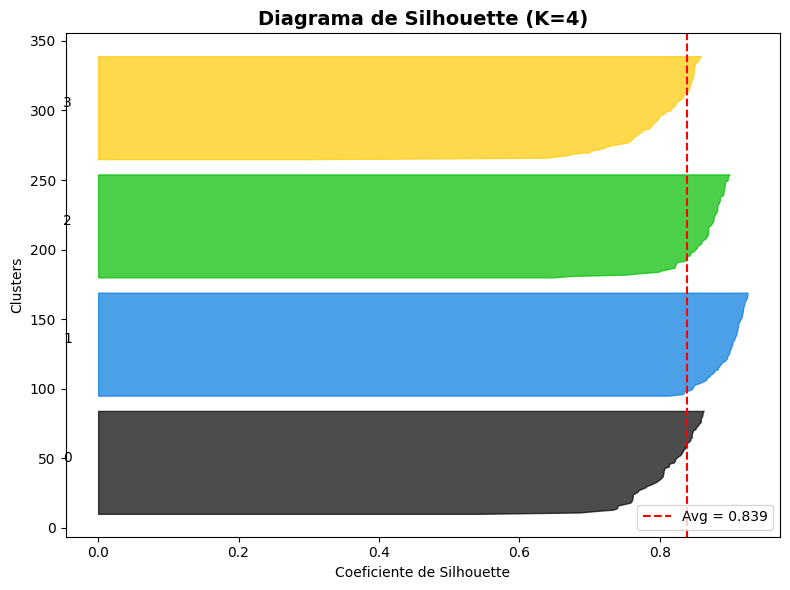


Silhouette Score promedio: 0.8386


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10

sample_silhouette_values = silhouette_samples(X_scaled, labels)
avg_score = silhouette_score(X_scaled, labels)

for i in range(4):
    cluster_vals = np.sort(sample_silhouette_values[labels == i])
    size_i = cluster_vals.shape[0]
    y_upper = y_lower + size_i

    color = cm.nipy_spectral(float(i) / 4)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                    facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=avg_score, color='red', linestyle='--', label=f'Avg = {avg_score:.3f}')
ax.set_title('Diagrama de Silhouette (K=4)', fontsize=14, fontweight='bold')
ax.set_xlabel('Coeficiente de Silhouette')
ax.set_ylabel('Clusters')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nSilhouette Score promedio: {avg_score:.4f}')